In [9]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import cartopy
import cartopy.crs as ccrs
import tqdm
from netCDF4 import Dataset
import xarray as xr
from ll_xy import lonlat_to_xy
from scipy.spatial import KDTree

In [13]:
df = pd.read_hdf('../aux_data/ridged_fraction.h5')
df

df['x'],df['y']=lonlat_to_xy(np.array(df['lon']),
                             np.array(df['lat']),
                             hemisphere='n')
df.reset_index()

,index,lon,lat,frac,x,y
0,0,-83.926418,73.474074,0.000000,-1.821022e+06,-1.937619e+05
1,1,-83.932355,73.485746,0.000000,-1.819765e+06,-1.934375e+05
2,2,-84.206472,74.013166,0.142249,-1.762906e+06,-1.788683e+05
3,3,-84.240094,74.075972,0.000000,-1.756130e+06,-1.771396e+05
4,4,-84.262912,74.118155,0.291808,-1.751578e+06,-1.759759e+05
...,...,...,...,...,...,...
120856,251,173.187424,70.832760,0.216526,2.516506e+05,2.106473e+06
120857,252,173.170524,70.788917,0.342509,2.528436e+05,2.111172e+06
120858,253,173.151378,70.739005,0.164199,2.542016e+05,2.116520e+06
120859,254,173.131217,70.686212,0.408239,2.556385e+05,2.122177e+06


In [14]:
# psn_lonlat = Dataset('../aux_data/NSIDC0771_LatLon_PS_N25km_v1.1.nc')
# psn_lon = np.array(psn_lonlat['longitude'])
# psn_lat = np.array(psn_lonlat['latitude'])

grid_d = Dataset('../aux_data/NSIDC0771_LatLon_PS_N12.5km_v1.1.nc')
lon,lat=np.array(grid_d['longitude']),np.array(grid_d['latitude'])
psn_lon = np.fliplr(np.rot90(np.rot90(lon)))
psn_lat = np.fliplr(np.rot90(np.rot90(lat)))

x,y=lonlat_to_xy(psn_lon,psn_lat,hemisphere='n')

tree = KDTree(list(zip(x.flatten(),y.flatten())))

q=tree.query(list(zip(df['x'],df['y'])))
df['ind0']=q[1]

In [15]:
unrav = np.unravel_index(df['ind0'],psn_lon.shape)
unique_indices = set(df['ind0'])
frac_grid = np.full(psn_lon.shape,np.nan)

for ind in unique_indices:
    dfind = df[df['ind0']==ind]
    mean_frac = np.nanmean(dfind['frac'])
    i,j = np.unravel_index(ind,psn_lon.shape)
    # print(i,j,mean_frac)
    frac_grid[i,j]=mean_frac

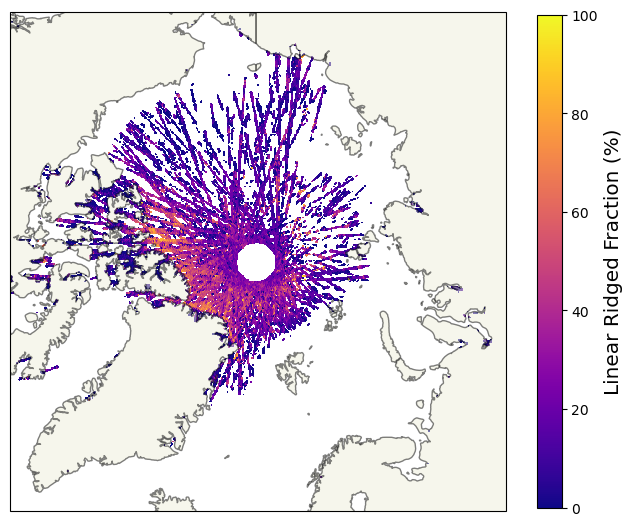

In [16]:
fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)

m = ax.pcolormesh(psn_lon,
                  psn_lat,
                  100*frac_grid,
                  vmin = 0,
                  vmax = 100,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

cb = fig.colorbar(m,shrink=0.8)
cb.set_label('Linear Ridged Fraction (%)',fontsize='x-large')

# plt.savefig('../figs/linear_ridged_frac_grid.png',dpi=500,bbox_inches='tight')

In [17]:
conc=np.array(Dataset('conc.nc')['sea_ice_conc'])
conc

array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [18]:
conc[conc>0.1]=1
conc[conc<=0.1]=0
conc[np.isnan(conc)]=0
conc[psn_lat<66]=0

In [19]:
inds_to_fill=np.argwhere(np.isnan(frac_grid)&(conc==1))
xys = [(x[i,j],y[i,j]) for i,j in inds_to_fill]
track_tree = KDTree(list(zip(df['x'],df['y'])))



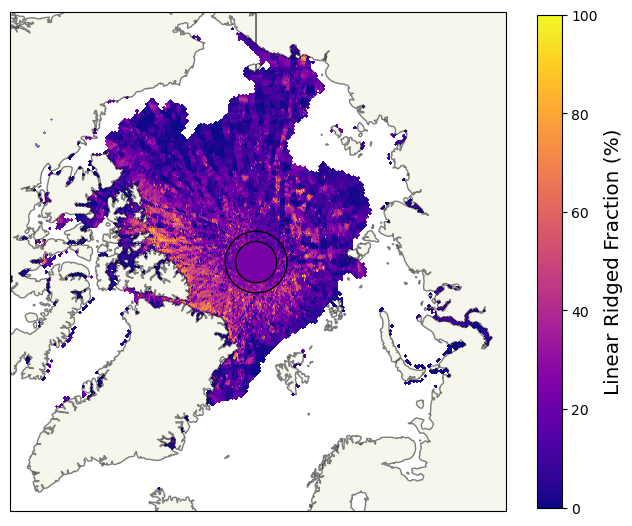

In [20]:
tree_output=track_tree.query(xys,k=10)
mean_fractions=[np.nanmean(df.iloc[ind]['frac']) for ind in tree_output[1]]

frac_grid_filled=frac_grid.copy()
for (i,j),mean_frac in zip(inds_to_fill,mean_fractions):
    frac_grid_filled[i,j] = mean_frac

frac_grid_filled[psn_lat>88]=np.nanmean(frac_grid_filled[(psn_lat>87)&(psn_lat<88)])

frac_grid_filled[conc<0.1]=np.nan

fig = plt.figure(figsize=(8,8))
proj = ccrs.NorthPolarStereo()
ax = plt.axes(projection=proj)
ax.set_extent([-180, 180, 90, 66], ccrs.PlateCarree())
ax.add_feature(cartopy.feature.LAND, edgecolor='black',zorder=1,alpha=0.5)

m = ax.pcolormesh(psn_lon,
                  psn_lat,
                  100*frac_grid_filled,
                  vmin = 0,
                  vmax = 100,
                 transform=ccrs.PlateCarree(),
                  zorder=0,
                  cmap='plasma',
                 )

ax.gridlines(ylocs=[87,88],xlocs=[],color='k',linewidth=1,zorder=10)

cb = fig.colorbar(m,shrink=0.8)
cb.set_label('Linear Ridged Fraction (%)',fontsize='x-large')


In [22]:
dnc = xr.DataArray(name='ridged_fraction_filled',
    data=frac_grid_filled,
    coords={'latitude':(['x','y'],lat),
            'longitude':(['x','y'],lon),
           },
    dims=['x','y'],
)

dnc.to_netcdf('rf.nc')